### Полиномиальная регрессия
Возможные варианты улучшения линейной регрессии - добавить для признаков полиномы более высокой степени
Полиномиальная регрессия решает две задачи - моделирование нелинейной связи (когда все точки лежат не на прямой линии, а на какой-то прямой) и взаимодействие между отдельными признаками

### Создание обученной модели с полиномальной регрессией
Благодаря добавлению полинома создается больш признаков на которых будет проходить обучение модели для предстоящей линейной регрессии.
Новый набор признаков разбивается на тестовый и обучающий наборы 
fit() в Scikit-Learn необходим чтобы определиться с диапазоном значений данных, а затем transform() - для преобразования данных. fit_transform() - объединяем два этих метода.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../course_data/08-Linear-Regression-Models/Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
X = df.drop('sales',axis=1)

In [4]:
y = df['sales']

In [5]:
from sklearn.preprocessing import PolynomialFeatures

In [6]:
polynomial_convert = PolynomialFeatures(degree=2,include_bias=False)

In [7]:
polynomial_convert.fit(X)

PolynomialFeatures(include_bias=False)

In [8]:
poly_features = polynomial_convert.transform(X)
poly_features

array([[ 230.1 ,   37.8 ,   69.2 , ..., 1428.84, 2615.76, 4788.64],
       [  44.5 ,   39.3 ,   45.1 , ..., 1544.49, 1772.43, 2034.01],
       [  17.2 ,   45.9 ,   69.3 , ..., 2106.81, 3180.87, 4802.49],
       ...,
       [ 177.  ,    9.3 ,    6.4 , ...,   86.49,   59.52,   40.96],
       [ 283.6 ,   42.  ,   66.2 , ..., 1764.  , 2780.4 , 4382.44],
       [ 232.1 ,    8.6 ,    8.7 , ...,   73.96,   74.82,   75.69]])

In [9]:
poly_features.shape

(200, 9)

In [10]:
X.shape

(200, 3)

In [11]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [12]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [13]:
polynomial_convert.fit_transform(X)

array([[ 230.1 ,   37.8 ,   69.2 , ..., 1428.84, 2615.76, 4788.64],
       [  44.5 ,   39.3 ,   45.1 , ..., 1544.49, 1772.43, 2034.01],
       [  17.2 ,   45.9 ,   69.3 , ..., 2106.81, 3180.87, 4802.49],
       ...,
       [ 177.  ,    9.3 ,    6.4 , ...,   86.49,   59.52,   40.96],
       [ 283.6 ,   42.  ,   66.2 , ..., 1764.  , 2780.4 , 4382.44],
       [ 232.1 ,    8.6 ,    8.7 , ...,   73.96,   74.82,   75.69]])

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
## train_test_split -> нажимаем shift+tab -> копируем код из примера

In [16]:
poly_features.shape

(200, 9)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
model = LinearRegression()

In [20]:
model.fit(X_train, y_train)

LinearRegression()

In [21]:
test_predictions = model.predict(X_test)

In [22]:
model.coef_

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [24]:
MAE = mean_absolute_error(y_test, test_predictions)
MAE

0.4896798044803838

In [25]:
MSE = mean_squared_error(y_test, test_predictions)
MSE

0.4417505510403753

In [26]:
RMSE = np.sqrt(MSE)
RMSE

np.float64(0.6646431757269274)

### Важно убедиться что разбиение на обучающий и тестовые наборы данных были выполнены одинаково для обеих моделей
... это гарантируется тем что указаны одинаковые параметры в test_size и random_state

### Вывод - полиномиальная регрессия работает заметно лучше, чем линейная

In [27]:
model.coef_

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

In [28]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

###   Дилемма смещения-дисперсии (Bias-Variance Trade-off)
      недообучение vs переобучение

In [29]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [30]:
69.2**2

4788.64

#### 1. Создать различные степени полинома
#### 2. Разбить данные на обучающий и тестовый наборы данных
#### 3. Обучить модель
#### 4. Сохранить метрики RMSE для обучающего и тестового наборов данных
#### 5. Построить график с результатами - ошибка по степеням полинома

In [31]:
train_rmse_errors = []
test_rmse_errors = []

# создаем степени полинма
for d in range(1, 10):
    poly_converter = PolynomialFeatures(degree=d, include_bias=False)
    poly_features = poly_converter.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

    model = LinearRegression()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)


In [32]:
train_rmse_errors

[np.float64(1.734594124329376),
 np.float64(0.5879574085292232),
 np.float64(0.43393443569020673),
 np.float64(0.35170836883993495),
 np.float64(0.2509342964085938),
 np.float64(0.20953728551101827),
 np.float64(0.22046859153994317),
 np.float64(0.2714979027161063),
 np.float64(0.5132042855379929)]

In [33]:
test_rmse_errors

[np.float64(1.5161519375993877),
 np.float64(0.6646431757269274),
 np.float64(0.5803286825236476),
 np.float64(0.5077742639859423),
 np.float64(2.5758223594965197),
 np.float64(9.871409346164954),
 np.float64(41.33056641548232),
 np.float64(3103.1690816102614),
 np.float64(12768.354846010698)]

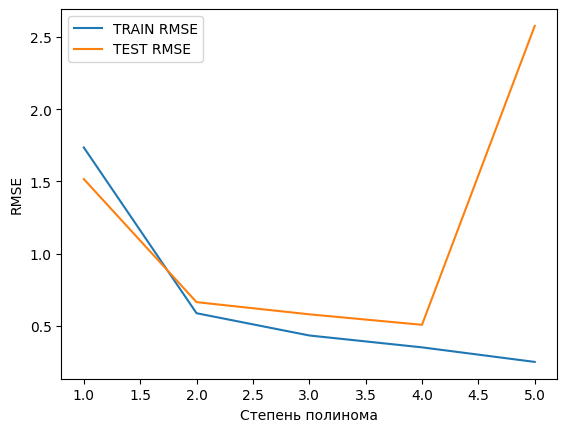

In [34]:
plt.plot(range(1,6), train_rmse_errors[:5], label='TRAIN RMSE')
plt.plot(range(1,6), test_rmse_errors[:5], label='TEST RMSE')

plt.xlabel('Степень полинома')
plt.ylabel('RMSE')
plt.legend();

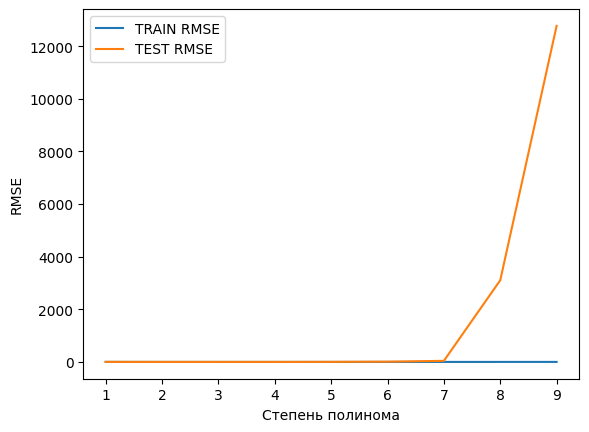

In [35]:
plt.plot(range(1,10), train_rmse_errors, label='TRAIN RMSE')
plt.plot(range(1,10), test_rmse_errors, label='TEST RMSE')

plt.xlabel('Степень полинома')
plt.ylabel('RMSE')
plt.legend();

#### Исходя из графиков для обучения моделеи полиномиальной регрессией лучше выбирать 2 или 3 степень полинома и

### Создаем финальную модель

In [36]:
final_poly_converter = PolynomialFeatures(degree=3, include_bias=False)

In [37]:
final_model = LinearRegression()

In [38]:
full_converted_X = final_poly_converter.fit_transform(X) 
final_model.fit(full_converted_X, y)

LinearRegression()

In [39]:
from joblib import dump, load

In [40]:
dump(final_model, 'final_poly_model.joblib')

['final_poly_model.joblib']

In [41]:
dump(final_poly_converter, 'final_converter.joblib')

['final_converter.joblib']

In [42]:
loaded_converter = load('final_converter.joblib')

In [43]:
loaded_model = load('final_poly_model.joblib')

In [44]:
campaign = [[149,22,21]]

In [45]:
loaded_converter.transform(campaign)

/home/andrew/Python projects/DS_ML_course/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[1.490000e+02, 2.200000e+01, 2.100000e+01, 2.220100e+04,
        3.278000e+03, 3.129000e+03, 4.840000e+02, 4.620000e+02,
        4.410000e+02, 3.307949e+06, 4.884220e+05, 4.662210e+05,
        7.211600e+04, 6.883800e+04, 6.570900e+04, 1.064800e+04,
        1.016400e+04, 9.702000e+03, 9.261000e+03]])

In [46]:
loaded_converter.transform(campaign).shape

/home/andrew/Python projects/DS_ML_course/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


(1, 19)

In [47]:
transformed_data = loaded_converter.transform(campaign)

/home/andrew/Python projects/DS_ML_course/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [48]:
loaded_model.predict(transformed_data)

array([14.60555347])

#### =============================================================================

#### Регуляризация - помогает решить несколько общих пробем машинного обучения. Для этого:
 - минимизация сложности модели
 - штрафы на функцию потерь
 - уменьшение переобученности модели (добавляя большее смещение, чтобы уменьшить дисперсию)

##### Три типа регуляризации:
 - L1-регуляризация - регрессия LASSO (добавляем штраф, равный абсолютному значению величин коэффициентов)
 - L2-регуляризация - регрессия RIDGE (добаляет штраф, равный квадрату величин коэффициентов)
 - Elastic Net - комбинация L1 и L2 (определяем соотношение между L1 и L2 с помощью параметра alpha)

#### ===============================================================================

##### .fit() - вызываем только для обучающих данных, потому что не нужно добавлять в модель каке-то знанияб которые содержаться в тестовых данных ! Он вычисляет необходимые метрики (Xmin, Xmax, среднее начение, дисперсия, etc)
##### .transfrom() - масштабирует данные и возвращает новую версию данных

#### ===============================================================================

#### Процесс масштабирования признаков
 - разбиваем данные на обучающий и тестовый наборы
 - вызываем .fit() только для обучающих данных
 - вызываем .transform() для обучающих данных
 - вызываем .transform() для тестовых данных 

#### ===============================================================================

In [49]:
print('test msg')

test msg
